In [1]:
%load_ext autoreload
%autoreload 2
import os
import numpy as np
from IPython.display import display
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torchvision import transforms
from torch.utils.data import DataLoader
import wandb
import h5py

import sys
sys.path.append('../../src/benchmark/')
sys.path.append('../../src/utils/')

from train_functions import train_epochs, valid
from utils import split_train_valid, list_to_dict, viz_dataloader, hdf5_dataset
from viz import show_images
from build_model import ScaleAdaptiveModel, resnet50_

def compare_non_bn_parameters(model1, model2):
    model1_dict = model1.state_dict()
    model2_dict = model2.state_dict()

    for key in model1_dict:
        if key in model2_dict:
            # Check if the parameter is part of a Batch Normalization layer
            if 'running_mean' in key or 'running_var' in key or 'num_batches_tracked' in key:
                continue  # Skip batch normalization parameters
            
            # Check if the weights are the same
            if torch.equal(model1_dict[key], model2_dict[key]):
                # continue
                print(f"Weights/Biases for {key} are the same.")
            else:
                # Compute the difference and display it
                diff = torch.abs(model1_dict[key] - model2_dict[key]).float()
                mean_diff = torch.mean(diff).item()
                max_diff = torch.max(diff).item()
                print(f"Weights/Biases for {key} differ: Mean diff = {mean_diff}, Max diff = {max_diff}")
        else:
            print(f"{key} is not present in both models.")



# Load your pretrained ResNet50 model
pretrained_resnet50 = resnet50_(3, 17)
pretrained_resnet50 = torch.load('../../saved_models/05242024-benchmark-ResNet50-v5_10m/epoch-20.pt').module

# Freeze all the parameters in the backbone
for param in pretrained_resnet50.parameters():
    param.requires_grad = False
    
pretrained_resnet50
device = torch.device('cuda:0')
loss_func = nn.CrossEntropyLoss()


# Instantiate your model
model = ScaleAdaptiveModel(pretrained_resnet50)

input_tensor = torch.randn((2, 3, 256, 256))  # Example input
output = model(input_tensor)
print(output.shape)  # Output shape from the backbone

# model = torch.nn.DataParallel(model, device_ids=[0,1])
# model

torch.Size([2, 17])


## verify without train the first layer

In [ ]:
symmetry_classes = ['p1', 'p2', 'pm', 'pg', 'cm', 'pmm', 'pmg', 'pgg', 'cmm', 'p4', 'p4m', 'p4g', 'p3', 'p3m1', 'p31m', 'p6', 'p6m']
label_converter = list_to_dict(symmetry_classes)
bs = 800

# imagenet
imagenet_ds = hdf5_dataset('../../../imagenet_v5_rot_10m.h5', folder='train', transform=transforms.ToTensor())
train_ds, valid_ds = split_train_valid(imagenet_ds, 0.8)
train_dl = DataLoader(train_ds, batch_size=bs, shuffle=True, num_workers=2)
viz_dataloader(train_dl, label_converter=label_converter, title='imagenet - train')
valid_dl = DataLoader(valid_ds, batch_size=bs, shuffle=False, num_workers=2)
viz_dataloader(valid_dl, label_converter=label_converter, title='imagenet - valid')

# # atom
atom_ds = hdf5_dataset('../../../atom_v5_rot_200k.h5', folder='test', transform=transforms.ToTensor())
atom_dl = DataLoader(atom_ds, batch_size=bs, shuffle=False, num_workers=2)
viz_dataloader(atom_dl, label_converter=label_converter, title='atom - cv')

# # noise
noise_ds = hdf5_dataset('../../../imagenet_atom_noise_v4_rot_10m_100k_subset.h5', folder='noise', transform=transforms.ToTensor())
noise_dl = DataLoader(noise_ds, batch_size=bs, shuffle=False, num_workers=2)
viz_dataloader(noise_dl, label_converter=label_converter, title='noise - cv')

In [15]:
model_ = resnet50_(3, 17)
model_ = torch.load('../../epoch-20.pt').module

avg_valid_loss, avg_valid_acc = valid(model_, loss_func, device, valid_dl, task_label='valid', tracking=False)
print(f"Validation: Loss: {avg_valid_loss:.4f}, Accuracy: {avg_valid_acc*100:.4f}%.")

avg_valid_loss, avg_valid_acc = valid(model_, loss_func, device, atom_dl, task_label='cv_atom', tracking=False)
print(f"Validation: Loss: {avg_valid_loss:.4f}, Accuracy: {avg_valid_acc*100:.4f}%.")

avg_valid_loss, avg_valid_acc = valid(model_, loss_func, device, noise_dl, task_label='cv_noise', tracking=False)
print(f"Validation: Loss: {avg_valid_loss:.4f}, Accuracy: {avg_valid_acc*100:.4f}%.")

100%|██████████| 1072/1072 [37:21<00:00,  2.09s/it]


Validation: Loss: 0.0475, Accuracy: 98.6061%.


100%|██████████| 102/102 [03:33<00:00,  2.09s/it]


Validation: Loss: 1.5500, Accuracy: 84.0936%.


100%|██████████| 51/51 [01:47<00:00,  2.11s/it]

Validation: Loss: 0.2511, Accuracy: 95.8961%.


In [16]:
device = torch.device('cuda:0')
loss_func = nn.CrossEntropyLoss()

for param in model.parameters():
    param.requires_grad = False
  
avg_valid_loss, avg_valid_acc = valid(model_, loss_func, device, valid_dl, task_label='valid', tracking=False)
print(f"Validation: Loss: {avg_valid_loss:.4f}, Accuracy: {avg_valid_acc*100:.4f}%.")

avg_valid_loss, avg_valid_acc = valid(model_, loss_func, device, atom_dl, task_label='cv_atom', tracking=False)
print(f"Validation: Loss: {avg_valid_loss:.4f}, Accuracy: {avg_valid_acc*100:.4f}%.")

avg_valid_loss, avg_valid_acc = valid(model_, loss_func, device, noise_dl, task_label='cv_noise', tracking=False)
print(f"Validation: Loss: {avg_valid_loss:.4f}, Accuracy: {avg_valid_acc*100:.4f}%.")

  0%|          | 0/1072 [00:00<?, ?it/s]

100%|██████████| 1072/1072 [37:37<00:00,  2.11s/it]


Validation: Loss: 0.0475, Accuracy: 98.6061%.


100%|██████████| 102/102 [03:34<00:00,  2.10s/it]


Validation: Loss: 1.5500, Accuracy: 84.0936%.


100%|██████████| 51/51 [01:47<00:00,  2.11s/it]


Validation: Loss: 0.2511, Accuracy: 95.8961%.


## fine tune the first layer

In [2]:
# Freeze all the parameters in the backbone but the affine transformation layer
for param in model.parameters():
    param.requires_grad = False
    
for param in model.stn.parameters():
    param.requires_grad = True
    
# Verify which parts are trainable
for name, param in model.named_parameters():
    print(f"{name} is {'trainable' if param.requires_grad else 'frozen'}")

backbone.conv1.weight is frozen
backbone.bn1.weight is frozen
backbone.bn1.bias is frozen
backbone.layer1.0.conv1.weight is frozen
backbone.layer1.0.bn1.weight is frozen
backbone.layer1.0.bn1.bias is frozen
backbone.layer1.0.conv2.weight is frozen
backbone.layer1.0.bn2.weight is frozen
backbone.layer1.0.bn2.bias is frozen
backbone.layer1.0.conv3.weight is frozen
backbone.layer1.0.bn3.weight is frozen
backbone.layer1.0.bn3.bias is frozen
backbone.layer1.0.downsample.0.weight is frozen
backbone.layer1.0.downsample.1.weight is frozen
backbone.layer1.0.downsample.1.bias is frozen
backbone.layer1.1.conv1.weight is frozen
backbone.layer1.1.bn1.weight is frozen
backbone.layer1.1.bn1.bias is frozen
backbone.layer1.1.conv2.weight is frozen
backbone.layer1.1.bn2.weight is frozen
backbone.layer1.1.bn2.bias is frozen
backbone.layer1.1.conv3.weight is frozen
backbone.layer1.1.bn3.weight is frozen
backbone.layer1.1.bn3.bias is frozen
backbone.layer1.2.conv1.weight is frozen
backbone.layer1.2.bn1.wei

### this training is to fine tune on the target cross validation dataset - Atom Symmetry dataset with same uc size

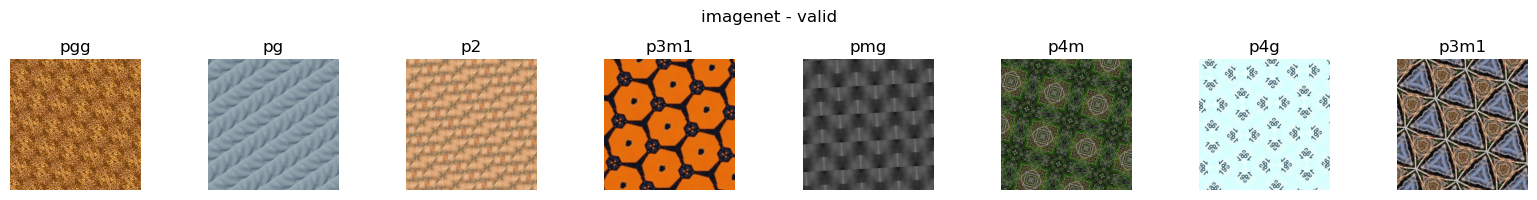

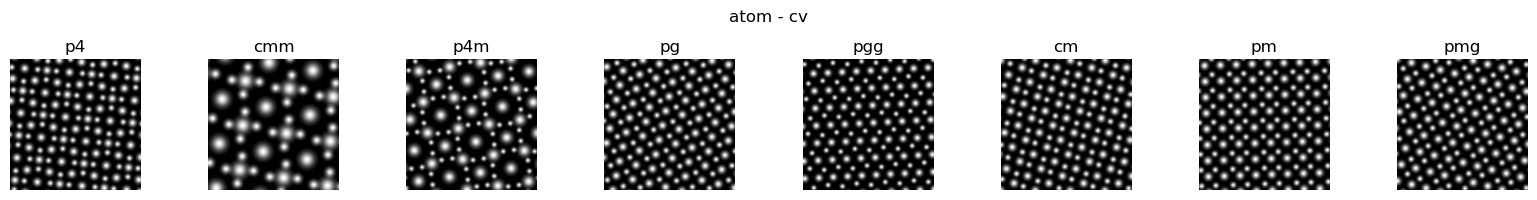

In [7]:
symmetry_classes = ['p1', 'p2', 'pm', 'pg', 'cm', 'pmm', 'pmg', 'pgg', 'cmm', 'p4', 'p4m', 'p4g', 'p3', 'p3m1', 'p31m', 'p6', 'p6m']
label_converter = list_to_dict(symmetry_classes)
bs = 400

# imagenet
imagenet_ds = hdf5_dataset('../../../imagenet_v5_rot_10m.h5', folder='train', transform=transforms.ToTensor())
_, valid_ds = split_train_valid(imagenet_ds, 0.98)
valid_dl = DataLoader(valid_ds, batch_size=bs, shuffle=False, num_workers=2)
viz_dataloader(valid_dl, label_converter=label_converter, title='imagenet - valid')

# # atom
atom_ds = hdf5_dataset('../../../atom_v5_rot_200k.h5', folder='test', transform=transforms.ToTensor())
atom_dl = DataLoader(atom_ds, batch_size=bs, shuffle=True, num_workers=2)
viz_dataloader(atom_dl, label_converter=label_converter, title='atom - cv')

plt.show()

In [8]:
device = torch.device('cuda:0')
# model = torch.nn.DataParallel(model, device_ids=[0,2])

lr = 1e-3
start = 0
epochs = 50

loss_func = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=lr)
scheduler = torch.optim.lr_scheduler.OneCycleLR(optimizer, epochs=epochs, max_lr=lr, steps_per_epoch=len(atom_dl))
history = train_epochs(model, loss_func, optimizer, device, atom_dl, valid_dl, cv_dl_list=[], cv_name_list=[], epochs=epochs, start=start, scheduler=scheduler)

Epoch: 1/50


  0%|          | 0/510 [00:00<?, ?it/s]

100%|██████████| 510/510 [07:45<00:00,  1.10it/s]


Training: Loss: 0.9328, Accuracy: 87.9279%.


100%|██████████| 536/536 [04:13<00:00,  2.12it/s]


...

Validation: Loss: 1.5078, Accuracy: 83.2181%.
Epoch: 50/50


100%|██████████| 510/510 [08:13<00:00,  1.03it/s]


Training: Loss: 0.8853, Accuracy: 88.1525%.


100%|██████████| 536/536 [08:45<00:00,  1.02it/s]

Validation: Loss: 1.5074, Accuracy: 83.3413%.


In [9]:
torch.save(model.state_dict(), '../../saved_models/spatial_finetune/atom_v5_rot_200k-weights-epoch-50.pt')

In [10]:
avg_valid_loss, avg_valid_acc = valid(model, loss_func, device, atom_dl, task_label='valid', tracking=False)
print(f"Validation: Loss: {avg_valid_loss:.4f}, Accuracy: {avg_valid_acc*100:.4f}%.")

100%|██████████| 510/510 [08:17<00:00,  1.02it/s]

Validation: Loss: 0.8299, Accuracy: 88.8534%.


In [6]:
# use the spatial model to recreate the resnet50 model to verify the weights are the same
model.load_state_dict(torch.load('../../saved_models/spatial_finetune/atom_v5_rot_200k-weights-epoch-50.pt'))
model_backbone = model.backbone
model_backbone.fc = model.fc_classifier
model_backbone = model_backbone.cpu()
# print(model_backbone)

model_ = resnet50_(3, 17)
model_ = torch.load('../../epoch-20.pt').module
model_ = model_.cpu()
# print(model_)

import torch
import torch.nn as nn

def compare_non_bn_parameters(model1, model2):
    model1_dict = model1.state_dict()
    model2_dict = model2.state_dict()

    for key in model1_dict:
        if key in model2_dict:
            # Check if the parameter is part of a Batch Normalization layer
            if 'running_mean' in key or 'running_var' in key or 'num_batches_tracked' in key:
                continue  # Skip batch normalization parameters
            
            # Check if the weights are the same
            if torch.equal(model1_dict[key], model2_dict[key]):
                # continue
                print(f"Weights/Biases for {key} are the same.")
            else:
                # Compute the difference and display it
                diff = torch.abs(model1_dict[key] - model2_dict[key]).float()
                mean_diff = torch.mean(diff).item()
                max_diff = torch.max(diff).item()
                print(f"Weights/Biases for {key} differ: Mean diff = {mean_diff}, Max diff = {max_diff}")
        else:
            print(f"{key} is not present in both models.")

# Example of usage
# Assuming model1 and model2 are two instances of the same architecture
compare_non_bn_parameters(model_backbone, model_)

Weights/Biases for conv1.weight are the same.
Weights/Biases for bn1.weight are the same.
Weights/Biases for bn1.bias are the same.
Weights/Biases for layer1.0.conv1.weight are the same.
Weights/Biases for layer1.0.bn1.weight are the same.
Weights/Biases for layer1.0.bn1.bias are the same.
Weights/Biases for layer1.0.conv2.weight are the same.
Weights/Biases for layer1.0.bn2.weight are the same.
Weights/Biases for layer1.0.bn2.bias are the same.
Weights/Biases for layer1.0.conv3.weight are the same.
Weights/Biases for layer1.0.bn3.weight are the same.
Weights/Biases for layer1.0.bn3.bias are the same.
Weights/Biases for layer1.0.downsample.0.weight are the same.
Weights/Biases for layer1.0.downsample.1.weight are the same.
Weights/Biases for layer1.0.downsample.1.bias are the same.
Weights/Biases for layer1.1.conv1.weight are the same.
Weights/Biases for layer1.1.bn1.weight are the same.
Weights/Biases for layer1.1.bn1.bias are the same.
Weights/Biases for layer1.1.conv2.weight are the

### from 960 to 1200 uc size

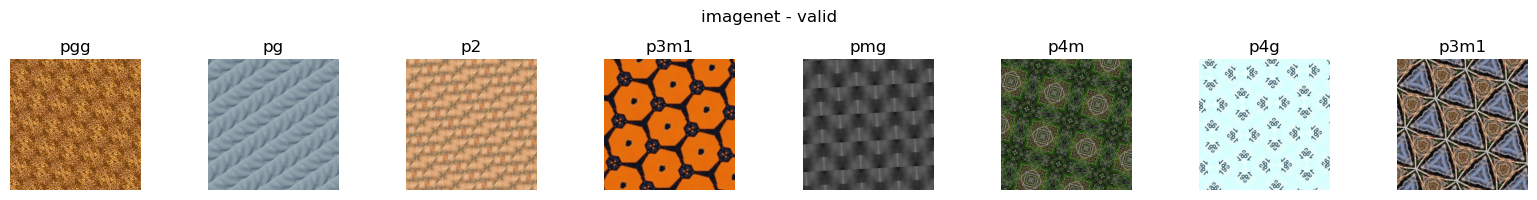

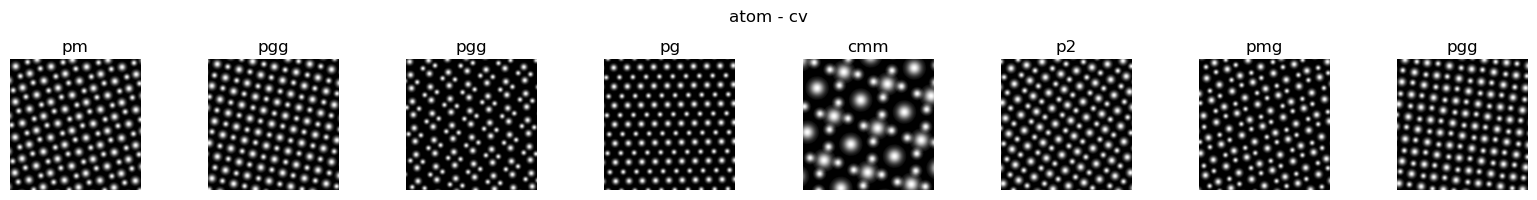

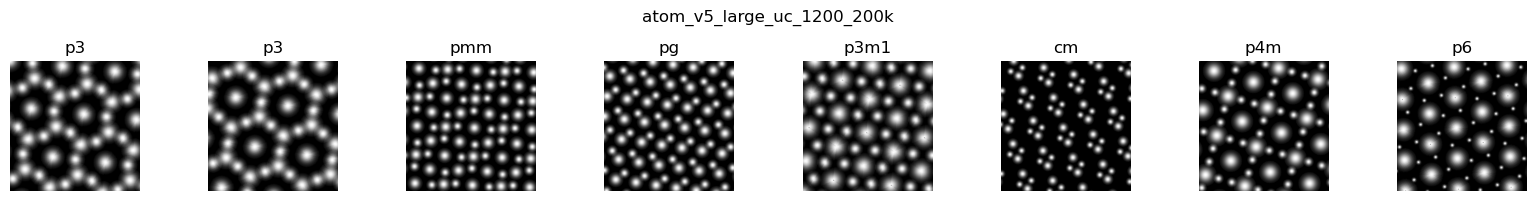

In [2]:
symmetry_classes = ['p1', 'p2', 'pm', 'pg', 'cm', 'pmm', 'pmg', 'pgg', 'cmm', 'p4', 'p4m', 'p4g', 'p3', 'p3m1', 'p31m', 'p6', 'p6m']
label_converter = list_to_dict(symmetry_classes)
bs = 1200

# imagenet
imagenet_ds = hdf5_dataset('../../../imagenet_v5_rot_10m.h5', folder='train', transform=transforms.ToTensor())
_, valid_ds = split_train_valid(imagenet_ds, 0.98)
valid_dl = DataLoader(valid_ds, batch_size=bs, shuffle=False, num_workers=6)
viz_dataloader(valid_dl, label_converter=label_converter, title='imagenet - valid')

# # atom
atom_ds = hdf5_dataset('../../../atom_v5_rot_200k.h5', folder='test', transform=transforms.ToTensor())
atom_dl = DataLoader(atom_ds, batch_size=bs, shuffle=True, num_workers=6)
viz_dataloader(atom_dl, label_converter=label_converter, title='atom - cv')

# atom_v5_large_uc_1200_200k
atom_v5_large_uc_1200_200k_ds = hdf5_dataset('../../../atom_v5_large_uc_1200_200k.h5', folder='test', transform=transforms.ToTensor())
atom_v5_large_uc_1200_200k_dl = DataLoader(atom_v5_large_uc_1200_200k_ds, batch_size=bs, shuffle=True, num_workers=6)
viz_dataloader(atom_v5_large_uc_1200_200k_dl, label_converter=label_converter, title='atom_v5_large_uc_1200_200k')

plt.show()

In [7]:
# Freeze all the parameters in the backbone but the affine transformation layer
for param in model.parameters():
    param.requires_grad = False
    
avg_valid_loss, avg_valid_acc = valid(model, loss_func, device, valid_dl, task_label='valid', tracking=False)
print(f"Validation: Loss: {avg_valid_loss:.4f}, Accuracy: {avg_valid_acc*100:.4f}%.")

avg_valid_loss, avg_valid_acc = valid(model, loss_func, device, atom_dl, task_label='cv_atom', tracking=False)
print(f"cv_atom - Validation: Loss: {avg_valid_loss:.4f}, Accuracy: {avg_valid_acc*100:.4f}%.")

avg_valid_loss, avg_valid_acc = valid(model, loss_func, device, atom_v5_large_uc_1200_200k_dl, task_label='atom_v5_large_uc_1200_200k', tracking=False)
print(f"atom_v5_large_uc_1200_200k - Validation: Loss: {avg_valid_loss:.4f}, Accuracy: {avg_valid_acc*100:.4f}%.")

100%|██████████| 268/268 [03:40<00:00,  1.21it/s]


Validation: Loss: 0.0456, Accuracy: 98.6387%.


100%|██████████| 255/255 [04:19<00:00,  1.02s/it]


cv_atom - Validation: Loss: 1.5499, Accuracy: 84.0946%.


100%|██████████| 256/256 [03:51<00:00,  1.10it/s]

atom_v5_large_uc_1200_200k - Validation: Loss: 11.3441, Accuracy: 19.2576%.


In [3]:
# Freeze all the parameters in the backbone but the affine transformation layer
for param in model.parameters():
    param.requires_grad = False
    
for param in model.stn.parameters():
    param.requires_grad = True
    
# Verify which parts are trainable
for name, param in model.named_parameters():
    print(f"{name} is {'trainable' if param.requires_grad else 'frozen'}")

backbone.conv1.weight is frozen
backbone.bn1.weight is frozen
backbone.bn1.bias is frozen
backbone.layer1.0.conv1.weight is frozen
backbone.layer1.0.bn1.weight is frozen
backbone.layer1.0.bn1.bias is frozen
backbone.layer1.0.conv2.weight is frozen
backbone.layer1.0.bn2.weight is frozen
backbone.layer1.0.bn2.bias is frozen
backbone.layer1.0.conv3.weight is frozen
backbone.layer1.0.bn3.weight is frozen
backbone.layer1.0.bn3.bias is frozen
backbone.layer1.0.downsample.0.weight is frozen
backbone.layer1.0.downsample.1.weight is frozen
backbone.layer1.0.downsample.1.bias is frozen
backbone.layer1.1.conv1.weight is frozen
backbone.layer1.1.bn1.weight is frozen
backbone.layer1.1.bn1.bias is frozen
backbone.layer1.1.conv2.weight is frozen
backbone.layer1.1.bn2.weight is frozen
backbone.layer1.1.bn2.bias is frozen
backbone.layer1.1.conv3.weight is frozen
backbone.layer1.1.bn3.weight is frozen
backbone.layer1.1.bn3.bias is frozen
backbone.layer1.2.conv1.weight is frozen
backbone.layer1.2.bn1.wei

In [4]:
model_path = '../../saved_models/spatial_finetune/atom_v5_rot_200k-finetune_scale_atom_uc_1200-weights-epoch-50.pt'

# Load the state dictionary from the file
state_dict = torch.load(model_path, map_location=torch.device('cpu'))
# model.load_state_dict(state_dict)

# Remove 'module.' prefix if it exists (this happens if model was trained using DataParallel or DistributedDataParallel)
new_state_dict = {key.replace('module.', ''): value for key, value in state_dict.items()}

# Load the adjusted state dict into your model
model.load_state_dict(new_state_dict)

<All keys matched successfully>

In [5]:
device = torch.device('cuda:0')
model = torch.nn.DataParallel(model, device_ids=[0,2,3])

lr = 1e-3
start = 20
epochs = 50

loss_func = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=lr)
scheduler = torch.optim.lr_scheduler.OneCycleLR(optimizer, epochs=epochs, max_lr=lr, steps_per_epoch=len(atom_dl))
history = train_epochs(model, loss_func, optimizer, device, atom_v5_large_uc_1200_200k_dl,
                       valid_dl_list=[atom_dl, valid_dl], valid_name_list=['atom_v5_uc_960_200k', 'Validation'], 
                       epochs=epochs, start=start, scheduler=scheduler, valid_every_epochs=10)

Epoch: 21/70


100%|██████████| 171/171 [03:17<00:00,  1.16s/it]


Training: Loss: 3.0213, Accuracy: 67.7500%.
Epoch: 22/70


100%|██████████| 171/171 [03:03<00:00,  1.07s/it]


Training: Loss: 3.0288, Accuracy: 67.8132%.
Epoch: 23/70


...

Training: Loss: 3.0268, Accuracy: 68.0411%.
Epoch: 69/70


100%|██████████| 171/171 [03:02<00:00,  1.07s/it]


Training: Loss: 3.0317, Accuracy: 68.0534%.
Epoch: 70/70


 71%|███████   | 121/171 [02:13<00:55,  1.11s/it]


ValueError: Tried to step 8501 times. The specified number of total steps is 8500

In [6]:
model_path = '../../saved_models/spatial_finetune/atom_v5_rot_200k-finetune_scale_atom_uc_1200-weights-epoch-50.pt'
torch.save(model.module.state_dict(), model_path)

In [14]:
# use the spatial model to recreate the resnet50 model to verify the weights are the same
# model.load_state_dict(torch.load(model_path))
model_backbone = model.module.backbone
model_backbone.fc = model.module.fc_classifier
model_backbone = model_backbone.cpu()
# print(model_backbone)

model_ = resnet50_(3, 17)
model_ = torch.load('../../saved_models/05242024-benchmark-ResNet50-v5_10m/epoch-20.pt').module
model_ = model_.cpu()
# print(model_)

# Example of usage
# Assuming model1 and model2 are two instances of the same architecture
compare_non_bn_parameters(model_backbone, model_)

Weights/Biases for conv1.weight are the same.
Weights/Biases for bn1.weight are the same.
Weights/Biases for bn1.bias are the same.
Weights/Biases for layer1.0.conv1.weight are the same.
Weights/Biases for layer1.0.bn1.weight are the same.
Weights/Biases for layer1.0.bn1.bias are the same.
Weights/Biases for layer1.0.conv2.weight are the same.
Weights/Biases for layer1.0.bn2.weight are the same.
Weights/Biases for layer1.0.bn2.bias are the same.
Weights/Biases for layer1.0.conv3.weight are the same.
Weights/Biases for layer1.0.bn3.weight are the same.
Weights/Biases for layer1.0.bn3.bias are the same.
Weights/Biases for layer1.0.downsample.0.weight are the same.
Weights/Biases for layer1.0.downsample.1.weight are the same.
Weights/Biases for layer1.0.downsample.1.bias are the same.
Weights/Biases for layer1.1.conv1.weight are the same.
Weights/Biases for layer1.1.bn1.weight are the same.
Weights/Biases for layer1.1.bn1.bias are the same.
Weights/Biases for layer1.1.conv2.weight are the

### from 960 to 600

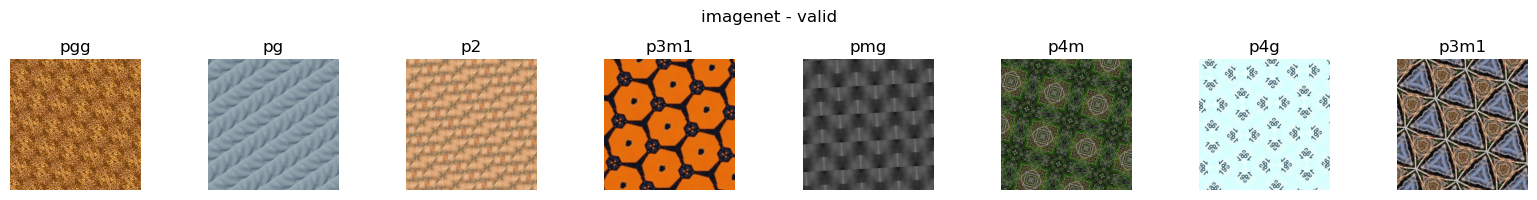

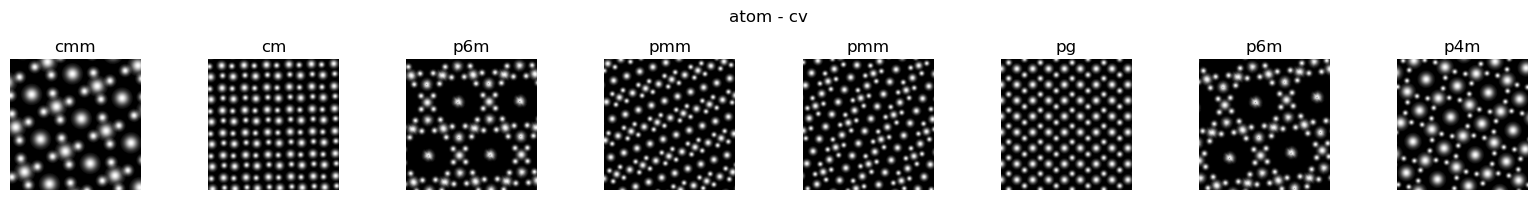

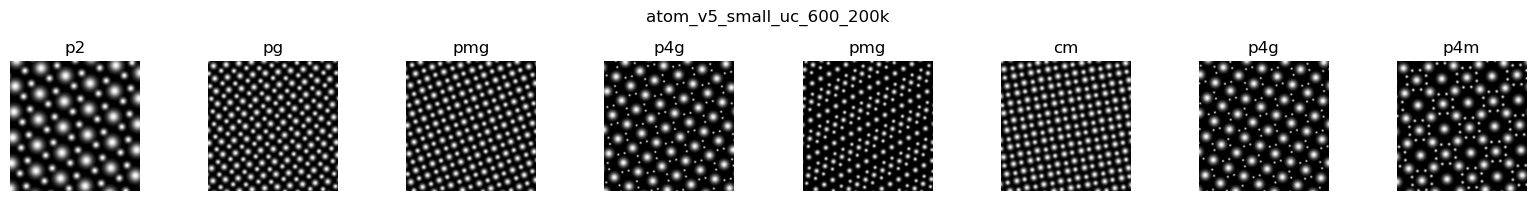

In [3]:
symmetry_classes = ['p1', 'p2', 'pm', 'pg', 'cm', 'pmm', 'pmg', 'pgg', 'cmm', 'p4', 'p4m', 'p4g', 'p3', 'p3m1', 'p31m', 'p6', 'p6m']
label_converter = list_to_dict(symmetry_classes)
bs = 1200

# imagenet
imagenet_ds = hdf5_dataset('../../../imagenet_v5_rot_10m.h5', folder='train', transform=transforms.ToTensor())
_, valid_ds = split_train_valid(imagenet_ds, 0.98)
valid_dl = DataLoader(valid_ds, batch_size=bs, shuffle=False, num_workers=6)
viz_dataloader(valid_dl, label_converter=label_converter, title='imagenet - valid')

# # atom
atom_ds = hdf5_dataset('../../../atom_v5_rot_200k.h5', folder='test', transform=transforms.ToTensor())
atom_dl = DataLoader(atom_ds, batch_size=bs, shuffle=True, num_workers=6)
viz_dataloader(atom_dl, label_converter=label_converter, title='atom - cv')

# atom_v5_small_uc_600_200k
atom_v5_small_uc_600_200k_ds = hdf5_dataset('../../../atom_v5_small_uc_600_200k.h5', folder='test', transform=transforms.ToTensor())
atom_v5_small_uc_600_200k_dl = DataLoader(atom_v5_small_uc_600_200k_ds, batch_size=bs, shuffle=True, num_workers=6)
viz_dataloader(atom_v5_small_uc_600_200k_dl, label_converter=label_converter, title='atom_v5_small_uc_600_200k')

plt.show()

#### benchmark record

In [6]:
# Freeze all the parameters in the backbone but the affine transformation layer
for param in model.parameters():
    param.requires_grad = False
    
avg_valid_loss, avg_valid_acc = valid(model, loss_func, device, valid_dl, task_label='valid', tracking=False)
print(f"Validation: Loss: {avg_valid_loss:.4f}, Accuracy: {avg_valid_acc*100:.4f}%.")

avg_valid_loss, avg_valid_acc = valid(model, loss_func, device, atom_dl, task_label='cv_atom', tracking=False)
print(f"cv_atom - Validation: Loss: {avg_valid_loss:.4f}, Accuracy: {avg_valid_acc*100:.4f}%.")

avg_valid_loss, avg_valid_acc = valid(model, loss_func, device, atom_v5_small_uc_600_200k_dl, task_label='atom_v5_small_uc_600_200k', tracking=False)
print(f"atom_v5_small_uc_600_200k - Validation: Loss: {avg_valid_loss:.4f}, Accuracy: {avg_valid_acc*100:.4f}%.")

  0%|          | 0/179 [00:00<?, ?it/s]

100%|██████████| 179/179 [04:09<00:00,  1.40s/it]


Validation: Loss: 0.0456, Accuracy: 98.6387%.


100%|██████████| 170/170 [03:52<00:00,  1.37s/it]


cv_atom - Validation: Loss: 1.5499, Accuracy: 84.0946%.


100%|██████████| 170/170 [03:52<00:00,  1.37s/it]

atom_v5_small_uc_600_200k - Validation: Loss: 8.9521, Accuracy: 24.4275%.


#### fine tune

In [7]:
# Freeze all the parameters in the backbone but the affine transformation layer
for param in model.parameters():
    param.requires_grad = False
    
for param in model.stn.parameters():
    param.requires_grad = True
    
# Verify which parts are trainable
for name, param in model.named_parameters():
    print(f"{name} is {'trainable' if param.requires_grad else 'frozen'}")

backbone.conv1.weight is frozen
backbone.bn1.weight is frozen
backbone.bn1.bias is frozen
backbone.layer1.0.conv1.weight is frozen
backbone.layer1.0.bn1.weight is frozen
backbone.layer1.0.bn1.bias is frozen
backbone.layer1.0.conv2.weight is frozen
backbone.layer1.0.bn2.weight is frozen
backbone.layer1.0.bn2.bias is frozen
backbone.layer1.0.conv3.weight is frozen
backbone.layer1.0.bn3.weight is frozen
backbone.layer1.0.bn3.bias is frozen
backbone.layer1.0.downsample.0.weight is frozen
backbone.layer1.0.downsample.1.weight is frozen
backbone.layer1.0.downsample.1.bias is frozen
backbone.layer1.1.conv1.weight is frozen
backbone.layer1.1.bn1.weight is frozen
backbone.layer1.1.bn1.bias is frozen
backbone.layer1.1.conv2.weight is frozen
backbone.layer1.1.bn2.weight is frozen
backbone.layer1.1.bn2.bias is frozen
backbone.layer1.1.conv3.weight is frozen
backbone.layer1.1.bn3.weight is frozen
backbone.layer1.1.bn3.bias is frozen
backbone.layer1.2.conv1.weight is frozen
backbone.layer1.2.bn1.wei

In [8]:
device = torch.device('cuda:0')
model = torch.nn.DataParallel(model, device_ids=[0,2,3])

lr = 1e-3
start = 0
epochs = 50

loss_func = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=lr)
scheduler = torch.optim.lr_scheduler.OneCycleLR(optimizer, epochs=epochs, max_lr=lr, steps_per_epoch=len(atom_dl))
history = train_epochs(model, loss_func, optimizer, device, atom_v5_small_uc_600_200k_dl, 
                       valid_dl_list=[atom_dl, valid_dl], valid_name_list=['atom_uc_960_dl', 'Validation'], 
                       epochs=epochs, start=start, scheduler=scheduler)

Epoch: 1/50


100%|██████████| 170/170 [03:42<00:00,  1.31s/it]


Training: Loss: 11.4382, Accuracy: 24.0549%.


100%|██████████| 170/170 [03:07<00:00,  1.10s/it]


atom_uc_960_dl: Loss: 2.2346, Accuracy: 79.0632%.


...

Training: Loss: 4.0527, Accuracy: 61.3696%.


100%|██████████| 170/170 [03:09<00:00,  1.12s/it]


atom_uc_960_dl: Loss: 9.5818, Accuracy: 25.8270%.


100%|██████████| 179/179 [03:21<00:00,  1.13s/it]

Validation: Loss: 7.4079, Accuracy: 46.8252%.


In [9]:
model_path = '../../saved_models/spatial_finetune/atom_v5_rot_200k-finetune_scale_atom_uc_600-weights-epoch-50.pt'
model = model.module.cpu()
torch.save(model.state_dict(), model_path)

In [11]:
# use the spatial model to recreate the resnet50 model to verify the weights are the same
# model.load_state_dict(torch.load(model_path))
model_backbone = model.backbone
model_backbone.fc = model.fc_classifier
model_backbone = model_backbone.cpu()
# print(model_backbone)

model_ = resnet50_(3, 17)
model_ = torch.load('../../saved_models/05242024-benchmark-ResNet50-v5_10m/epoch-20.pt').module
model_ = model_.cpu()
# print(model_)

# Example of usage
# Assuming model1 and model2 are two instances of the same architecture
compare_non_bn_parameters(model_backbone, model_)

Weights/Biases for conv1.weight are the same.
Weights/Biases for bn1.weight are the same.
Weights/Biases for bn1.bias are the same.
Weights/Biases for layer1.0.conv1.weight are the same.
Weights/Biases for layer1.0.bn1.weight are the same.
Weights/Biases for layer1.0.bn1.bias are the same.
Weights/Biases for layer1.0.conv2.weight are the same.
Weights/Biases for layer1.0.bn2.weight are the same.
Weights/Biases for layer1.0.bn2.bias are the same.
Weights/Biases for layer1.0.conv3.weight are the same.
Weights/Biases for layer1.0.bn3.weight are the same.
Weights/Biases for layer1.0.bn3.bias are the same.
Weights/Biases for layer1.0.downsample.0.weight are the same.
Weights/Biases for layer1.0.downsample.1.weight are the same.
Weights/Biases for layer1.0.downsample.1.bias are the same.
Weights/Biases for layer1.1.conv1.weight are the same.
Weights/Biases for layer1.1.bn1.weight are the same.
Weights/Biases for layer1.1.bn1.bias are the same.
Weights/Biases for layer1.1.conv2.weight are the

#### viz transform

In [7]:
model_path = '../../saved_models/spatial_finetune/atom_v5_rot_200k-finetune_scale_atom_uc_600-weights-epoch-50.pt'
model.load_state_dict(torch.load(model_path, map_location=torch.device('cpu')))
model

ScaleAdaptiveModel(
  (backbone): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (downsample): Sequential